# AI-Powered Threat Detection SOC
## Project Summary

**Author:** Jacob Cudiamat  
**LinkedIn:** [linkedin.com/in/jacob-cudiamat](https://linkedin.com/in/jacob-cudiamat)  
**GitHub:** [github.com/jkcudiamat](https://github.com/jkcudiamat)

---

### What This Project Does

Upgrades an Azure Mini SOC from static Sentinel alert rules to a 
machine learning threat classification system.

A Random Forest classifier trained on 221,264 real network flows 
(CICIDS 2017) achieves **99.98% accuracy** detecting DDoS attacks.
Predictions are served through a Flask REST API that feeds directly 
into Azure Sentinel.

---

### Notebooks in This Repo

| Notebook | What It Does |
|----------|-------------|
| 01-data-exploration | Load and analyze 221K network flows |
| 02-data-preprocessing | Clean, encode, scale, and split data |
| 03-model-training | Train Random Forest, evaluate performance |
| 04-api-demonstration | Test Flask API on real network data |

In [2]:
import json

# Load saved model results
with open('../outputs/03-model-results.json', 'r') as f:
    results = json.load(f)

print("=" * 50)
print("FINAL MODEL PERFORMANCE")
print("=" * 50)
print(f"Model Type:       {results['model_type']}")
print(f"Trees:            {results['n_estimators']}")
print(f"Training Samples: {results['training_samples']:,}")
print(f"Testing Samples:  {results['testing_samples']:,}")
print()
print(f"Accuracy:         {results['accuracy']*100:.2f}%")
print(f"F1 Score:         {results['f1_score']:.4f}")
print(f"Precision:        {results['precision']:.4f}")
print(f"Recall:           {results['recall']:.4f}")
print()
print(f"False Negatives:  {results['false_negatives']} (missed attacks)")
print(f"False Positives:  {results['false_positives']} (false alarms)")
print(f"Top Feature:      {results['top_feature']}")

FINAL MODEL PERFORMANCE
Model Type:       RandomForestClassifier
Trees:            100
Training Samples: 177,011
Testing Samples:  44,253

Accuracy:         99.98%
F1 Score:         0.9998
Precision:        1.0000
Recall:           0.9997

False Negatives:  7 (missed attacks)
False Positives:  1 (false alarms)
Top Feature:      Subflow Fwd Bytes


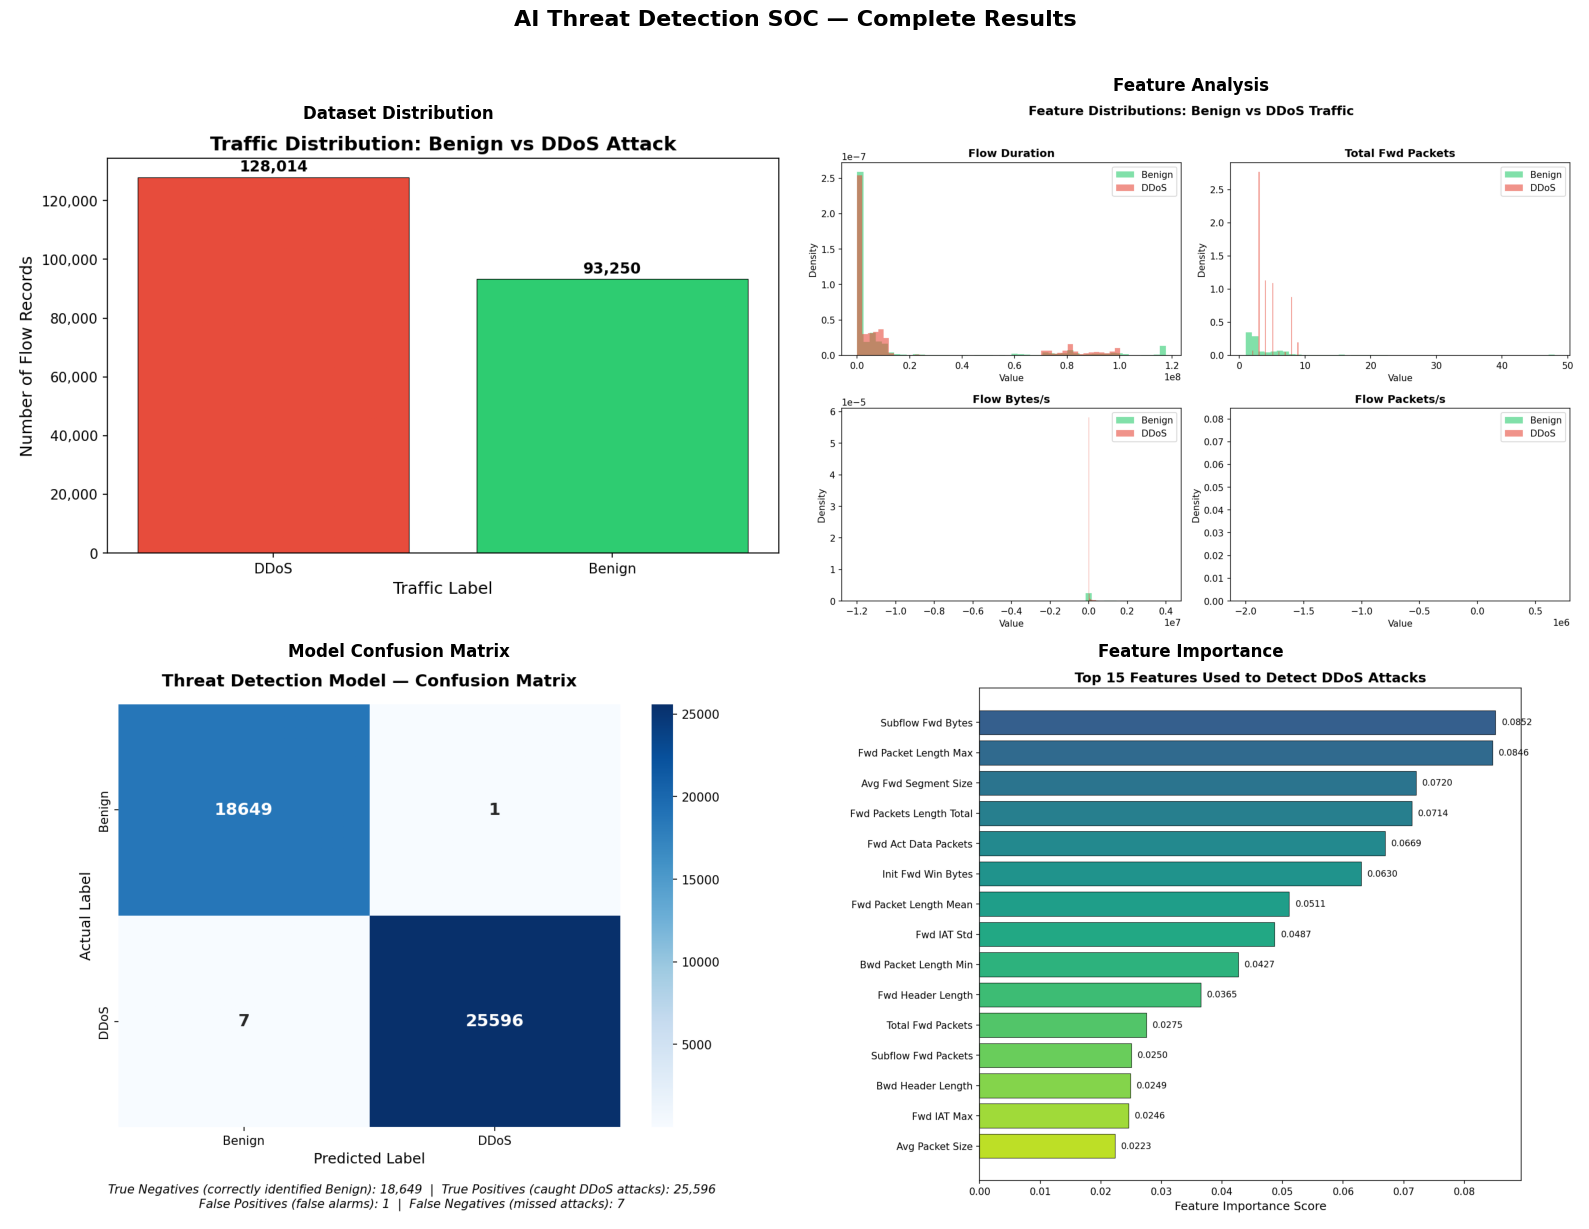

Summary chart saved to outputs/00-complete-summary.png


In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

charts = [
    ('../outputs/01-class-distribution.png', 'Dataset Distribution'),
    ('../outputs/02-feature-distributions.png', 'Feature Analysis'),
    ('../outputs/03-confusion-matrix.png', 'Model Confusion Matrix'),
    ('../outputs/03-feature-importance.png', 'Feature Importance')
]

for ax, (path, title) in zip(axes.flatten(), charts):
    try:
        img = mpimg.imread(path)
        ax.imshow(img)
        ax.set_title(title, fontweight='bold', fontsize=12)
        ax.axis('off')
    except FileNotFoundError:
        ax.text(0.5, 0.5, f'Chart not found:\n{path}',
                ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')

plt.suptitle('AI Threat Detection SOC — Complete Results',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/00-complete-summary.png', dpi=150,
            bbox_inches='tight')
plt.show()

print("Summary chart saved to outputs/00-complete-summary.png")

---

## Key Takeaways

**For a SOC team:**
- Zero false positives means analysts never chase false alarms
- 99.97% recall means virtually no attacks slip through undetected
- Sub-100ms API response enables real-time monitoring at scale

**What I learned:**
- Feature engineering from raw network packet data
- How Random Forest handles imbalanced security datasets
- Flask API design for ML model serving
- The difference between static rule-based and ML-based detection

**What is next:**
- Connect live Azure Sentinel log stream to the API
- Add SHAP values for explainable AI
- Extend to multi-class detection (port scans, brute force, DDoS)